In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

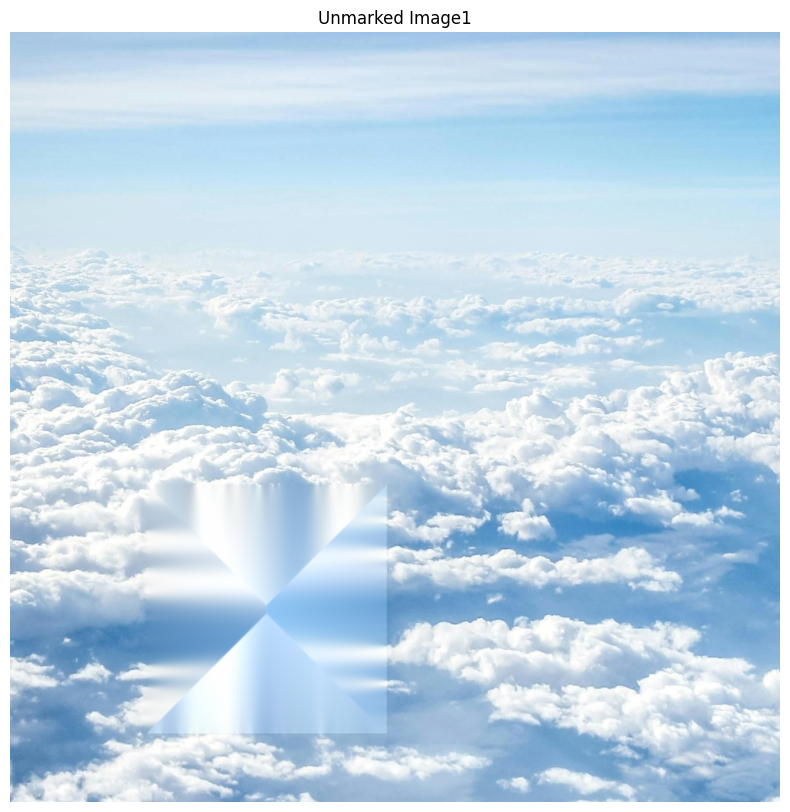

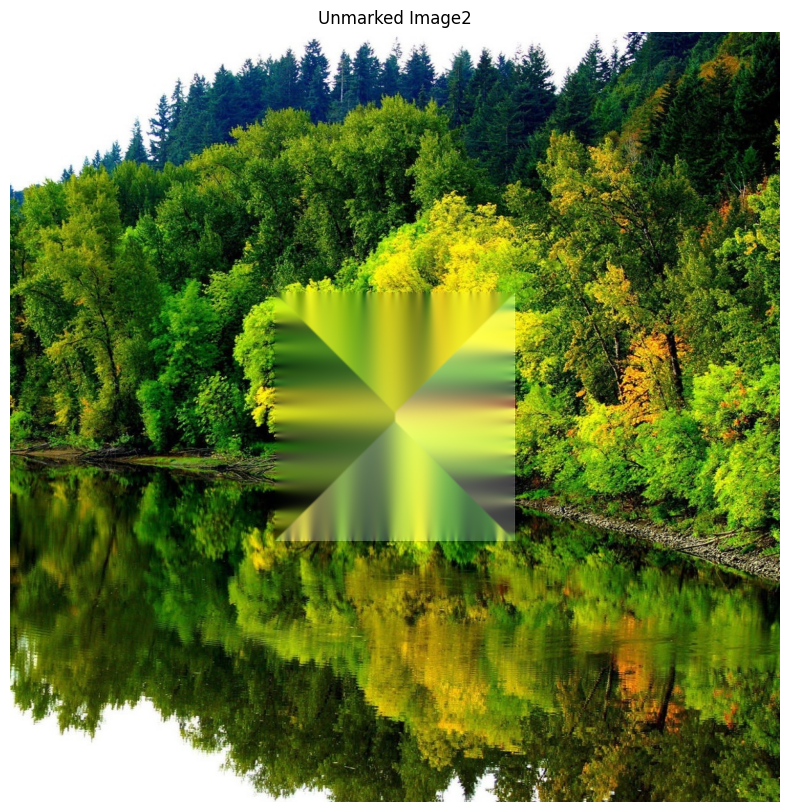

In [ ]:
def remove_watermark(image_path, coords):

    image = cv2.imread(image_path)

    x1, y1, x2, y2 = coords

    # Create a binary mask for the watermark region
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    mask[y1:y2, x1:x2] = 255  # Set the watermark region to 255 (white)

    # Apply inpainting to remove the watermark
    inpainted_image = cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    return inpainted_image

# Display the processed image
def display_image(image, title):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title(title)
    plt.show()

watermarked_image1 = "Watermarked_Image1.tiff"
watermarked_image2 = "Watermarked_Image2.tiff"

# Coordinates of the watermark in the image (top-left and bottom-right corners)
watermark_coords1 = (214, 707, 586, 1092)
watermark_coords2 = (414, 407, 786, 792)

# Remove the watermark
unmarked_image1 = remove_watermark(watermarked_image1, watermark_coords1)
unmarked_image2 = remove_watermark(watermarked_image2, watermark_coords2)

# Display the result
display_image(unmarked_image1, "Unmarked Image1")
display_image(unmarked_image2, "Unmarked Image2")

In [3]:
from scipy.fftpack import dct, idct
from skimage.metrics import mean_squared_error
import bz2
import pandas as pd

In [4]:
def apply_dct(image):
    return dct(dct(image.T, norm='ortho').T, norm='ortho')

def apply_idct(dct_coefficients):
    return idct(idct(dct_coefficients.T, norm='ortho').T, norm='ortho')

# Convert compressed bytes to bitstream
def bytes_to_bitstream(byte_data):
    bitstream = ''.join(format(byte, '08b') for byte in byte_data)
    return [bitstream[i:i + 8] for i in range(0, len(bitstream), 8)]

def calculate_bitstream_length(bitstream):
    length = len(bitstream)
    lsl = len(bitstream[-1]) if length > 0 else 0
    return 8 * (length - 1) + lsl

def encoder(image, quantization_factor=32, threshold=2):
    """
    Encodes a grayscale image into a compressed bitstream.
    Steps:
    1. Apply DCT
    2. Quantize DCT coefficients
    3. Apply thresholding for sparsity
    4. Flatten and compress using bz2
    """
    dct_coeffs = apply_dct(image)
    quantization_matrix = np.ones_like(dct_coeffs) * quantization_factor
    quantized = np.round(dct_coeffs / quantization_matrix)
    quantized[np.abs(quantized) < threshold] = 0
    flat_coeffs = quantized.flatten().astype(np.int16)
    compressed_bitstream = bz2.compress(flat_coeffs.tobytes())
    bitstream = bytes_to_bitstream(compressed_bitstream)
    return bitstream, quantization_matrix, quantized.shape

def decoder(bitstream, quantization_matrix, image_shape):
    """
    Decodes a compressed bitstream into a reconstructed grayscale image.
    """
    byte_data = bytes(int(bits, 2) for bits in bitstream if bits != "I")
    decompressed = np.frombuffer(bz2.decompress(byte_data), dtype=np.int16)
    quantized_coeffs = decompressed.reshape(image_shape)
    dequantized = quantized_coeffs * quantization_matrix
    reconstructed_image = apply_idct(dequantized)
    return np.clip(reconstructed_image, 0, 255)

# Evaluation Metric
def evaluate(original, reconstructed, bitstream_length):
    mse = mean_squared_error(original, reconstructed)
    compression_ratio = bitstream_length / (1200 * 1200 * 8)
    return mse, compression_ratio

# Convert to grayscale
grayscale_image1 = cv2.cvtColor(unmarked_image1, cv2.COLOR_BGR2GRAY)
grayscale_image2 = cv2.cvtColor(unmarked_image2, cv2.COLOR_BGR2GRAY)

# Encode
bitstream1, q_matrix1, shape1 = encoder(grayscale_image1)
bitstream2, q_matrix2, shape2 = encoder(grayscale_image2)

# Decode
reconstructed1 = decoder(bitstream1, q_matrix1, shape1)
reconstructed2 = decoder(bitstream2, q_matrix2, shape2)

# Evaluate
bitstream_length1 = calculate_bitstream_length(bitstream1)
bitstream_length2 = calculate_bitstream_length(bitstream2)
mse1, rho1 = evaluate(grayscale_image1, reconstructed1, bitstream_length1)
mse2, rho2 = evaluate(grayscale_image2, reconstructed2, bitstream_length2)

print(f"MSE1: {mse1:.4f}, Compression Ratio1: {rho1:.6f}")
print(f"MSE2: {mse2:.4f}, Compression Ratio2: {rho2:.6f}")
score = mse1 + mse2 + 200 ** (rho1 + rho2 + 1)
print(f"Score: {score:.4f}")

# Submission DataFrame
size1 = 1200 * 1200 - len(bitstream1)
size2 = 1200 * 1200 - len(bitstream2)
submission = pd.DataFrame({
    "ID": list(range(1200*1200)),
    "CompressedImage1": np.array(bitstream1 + ["I"] * size1),
    "CompressedImage2": np.array(bitstream2 + ["I"] * size2),
    "Image1": grayscale_image1.flatten(),
    "Image2": grayscale_image2.flatten(),
})

print(submission)
submission.to_csv("submission.csv", index=False)

MSE1: 29.4293, Compression Ratio1: 0.008363
MSE2: 192.3748, Compression Ratio2: 0.045553
Score: 487.9331
              ID CompressedImage1 CompressedImage2  Image1  Image2
0              0         01000010         01000010     190     255
1              1         01011010         01011010     190     255
2              2         01101000         01101000     190     255
3              3         00111001         00111001     190     255
4              4         00110001         00110001     190     255
...          ...              ...              ...     ...     ...
1439995  1439995                I                I     247      94
1439996  1439996                I                I     248      87
1439997  1439997                I                I     249      88
1439998  1439998                I                I     248      86
1439999  1439999                I                I     247      47

[1440000 rows x 5 columns]


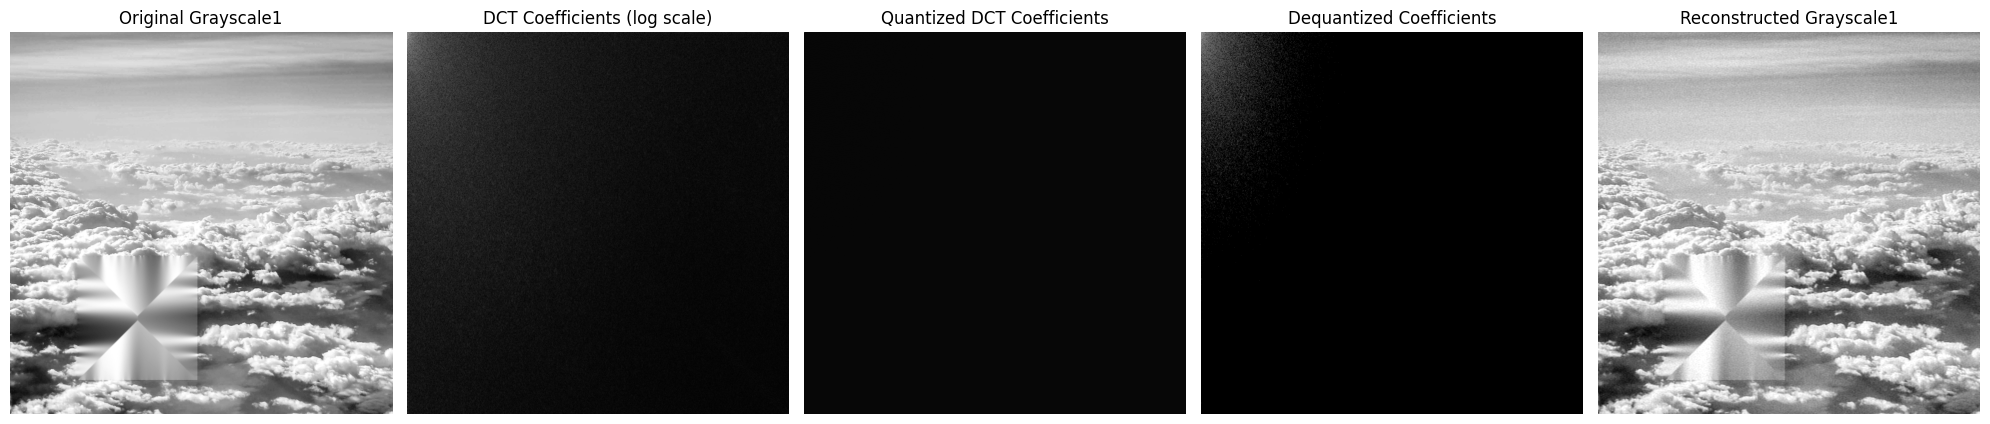

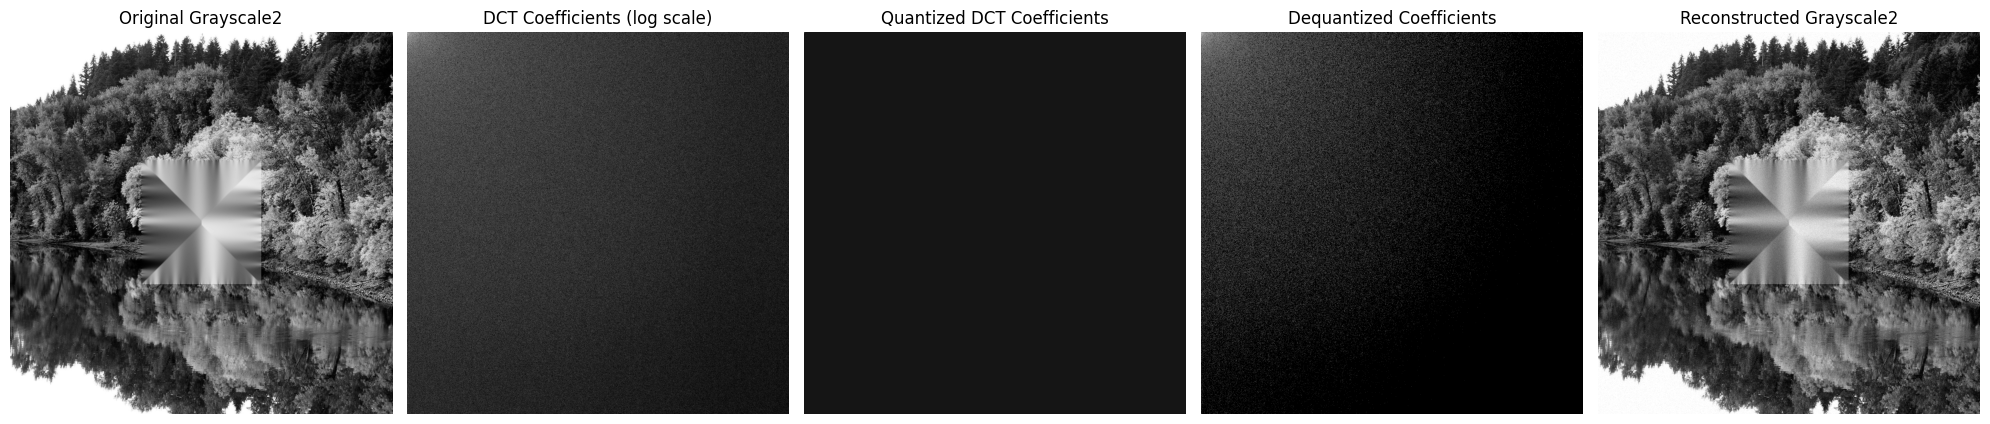

In [8]:
def visualize_stages(original_image, dct_coeffs, quantized, dequantized, reconstructed_image, title):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
    # Original Grayscale Image
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title(f"Original Grayscale{title}")
    axes[0].axis('off')
    
    # DCT Coefficients
    axes[1].imshow(np.log1p(np.abs(dct_coeffs)), cmap='gray')
    axes[1].set_title("DCT Coefficients (log scale)")
    axes[1].axis('off')
    
    # Quantized DCT Coefficients
    axes[2].imshow(quantized, cmap='gray')
    axes[2].set_title("Quantized DCT Coefficients")
    axes[2].axis('off')
    
    # Reconstructed DCT Coefficients (Dequantized)
    axes[3].imshow(np.log1p(np.abs(dequantized)), cmap='gray')
    axes[3].set_title("Dequantized Coefficients")
    axes[3].axis('off')
    
    # Reconstructed Grayscale Image
    axes[4].imshow(reconstructed_image, cmap='gray')
    axes[4].set_title(f"Reconstructed Grayscale{title}")
    axes[4].axis('off')
    
    plt.tight_layout()
    plt.show()

for image, title in [(unmarked_image1, 1), (unmarked_image2, 2)]:
    grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply DCT
    dct_coeffs = apply_dct(grayscale_image)
    
    # Quantize DCT coefficients
    quantization_factor = 32
    quantization_matrix = np.ones_like(dct_coeffs) * quantization_factor
    quantized = np.round(dct_coeffs / quantization_matrix)
    
    # Dequantize coefficients
    dequantized = quantized * quantization_matrix
    
    # Apply inverse DCT
    reconstructed_image = apply_idct(dequantized)
    reconstructed_image = np.clip(reconstructed_image, 0, 255)
    
    # Visualize the stages
    visualize_stages(grayscale_image, dct_coeffs, quantized, dequantized, reconstructed_image, title)

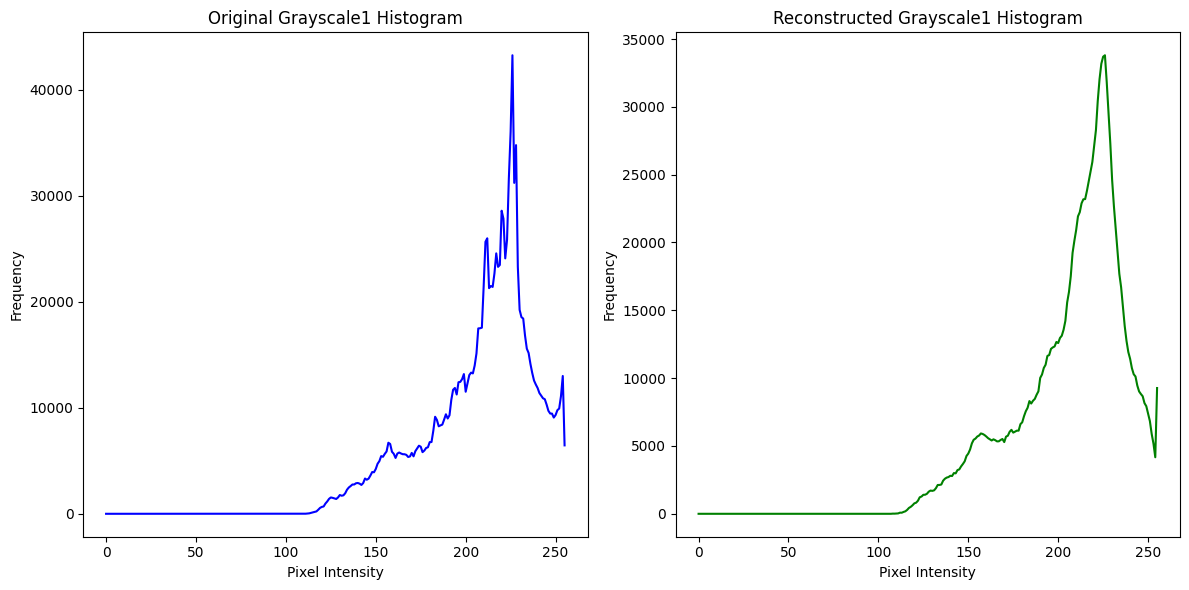

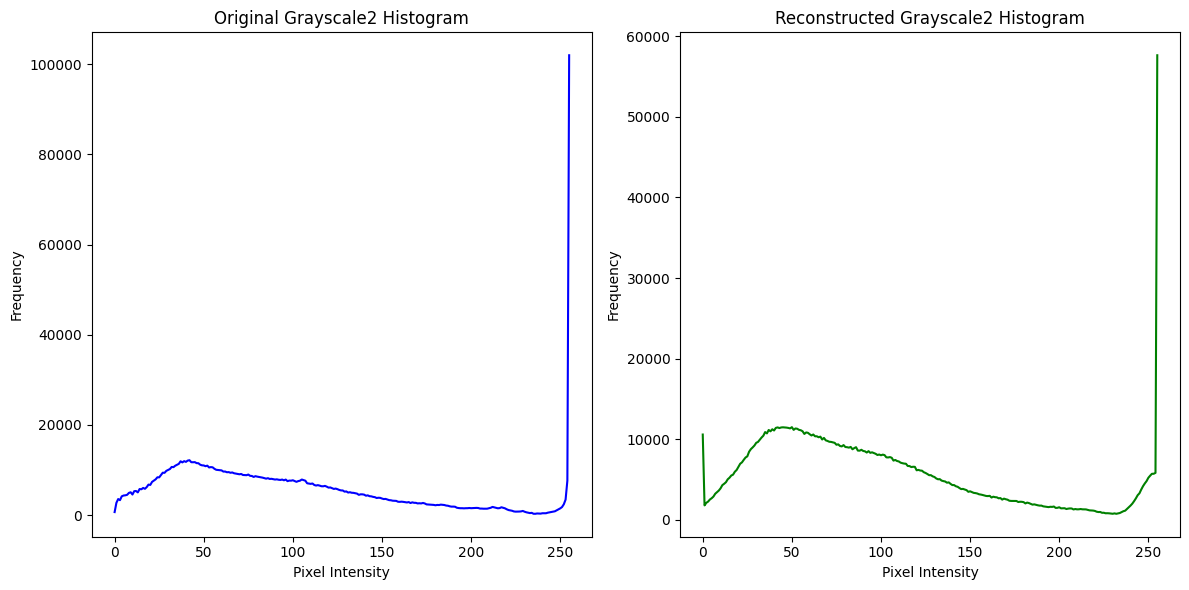

In [9]:
def plot_histograms(original_image, reconstructed_image, title):
    """
    Plots the histograms of the original and reconstructed grayscale images.
    """
    original_image = original_image.astype("uint8")
    reconstructed_image = reconstructed_image.astype("uint8")

    original_hist = cv2.calcHist([original_image], [0], None, [256], [0, 256])
    reconstructed_hist = cv2.calcHist([reconstructed_image], [0], None, [256], [0, 256])
    
    plt.figure(figsize=(12, 6))
    
    # Original image histogram
    plt.subplot(1, 2, 1)
    plt.plot(original_hist, color='blue')
    plt.title(f"Original Grayscale{title} Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    # Decompressed grayscale image histogram
    plt.subplot(1, 2, 2)
    plt.plot(reconstructed_hist, color='green')
    plt.title(f"Reconstructed Grayscale{title} Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

for image, title in [(unmarked_image1, 1), (unmarked_image2, 2)]:
    grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Encode and decode
    bitstream, q_matrix, shape = encoder(grayscale_image)
    reconstructed_image = decoder(bitstream, q_matrix, shape)
    
    # Plot histograms
    plot_histograms(grayscale_image, reconstructed_image, title)